In [ ]:

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Load the S&P 500 cleaned data
# Using the file uploaded by Abbinav
file_name = 'SP500_AdjClose_Cleaned.csv' 
df = pd.read_csv(file_name, index_col=0, parse_dates=True)

In [16]:
# Calculate Log Returns
log_returns = np.log(df / df.shift(1)).dropna()

# Compute Correlation and Distance Matrix
# d = sqrt(2 * (1 - rho)) as suggested for financial networks
corr_matrix = log_returns.corr()
dist_matrix = np.sqrt(2 * (1 - corr_matrix))


In [ ]:
# Minimum Spanning Tree (MST)
G_full = nx.from_pandas_adjacency(dist_matrix)
mst = nx.minimum_spanning_tree(G_full)


In [ ]:
# Threshold Network (e.g., Correlation > 0.5)
threshold = 0.5
# Create adjacency for threshold: 1 if corr > threshold, else 0
adj_threshold = (corr_matrix > threshold).astype(int)
# Remove self-loops (diagonal)
np.fill_diagonal(adj_threshold.values, 0)
threshold_net = nx.from_pandas_adjacency(adj_threshold)


In [ ]:
# Metric Analysis (Degree Distribution)
# Get degrees for MST
mst_degrees = dict(mst.degree())
top_hubs = sorted(mst_degrees.items(), key=lambda x: x[1], reverse=True)[:5]

print("Top 5 Hub Stocks in MST (Highest Connectivity):")
for stock, degree in top_hubs:
    print(f"{stock}: {degree} connections")


Top 5 Hub Stocks in MST (Highest Connectivity):
UTL_AEE: 16 connections
IND_PH: 13 connections
MAT_PPG: 13 connections
IND_DOV: 12 connections
IND_ITW: 12 connections


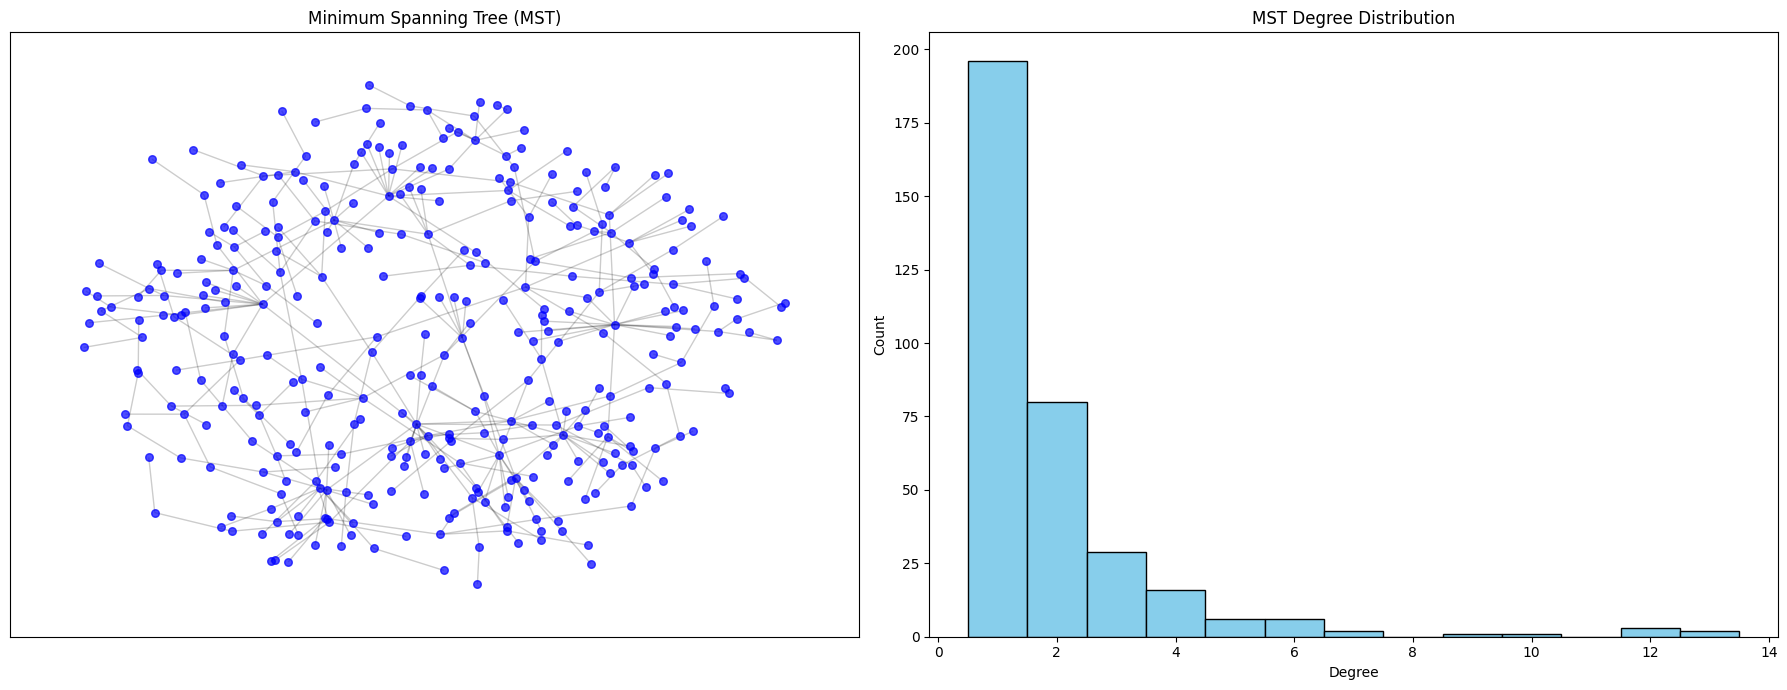

In [ ]:
# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot MST
pos_mst = nx.spring_layout(mst, k=0.15, seed=42)
nx.draw_networkx_nodes(mst, pos_mst, node_size=30, ax=axes[0], node_color='blue', alpha=0.7)
nx.draw_networkx_edges(mst, pos_mst, alpha=0.2, ax=axes[0])
axes[0].set_title("Minimum Spanning Tree (MST)")

# Plot Degree Distribution
axes[1].hist(list(mst_degrees.values()), bins=range(1, 15), color='skyblue', edgecolor='black', align='left')
axes[1].set_title("MST Degree Distribution")
axes[1].set_xlabel("Degree")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [21]:
# --- EXPORT DATA FOR TEAMMATES ---

# Export the Minimum Spanning Tree edges
# This captures the backbone of the market correlation
mst_df = nx.to_pandas_edgelist(mst)
mst_df.to_csv('mst_edges.csv', index=False)

# Export the Threshold Network edges (Correlation > 0.5)
# This is useful for simulating contagion across strong links
threshold_df = nx.to_pandas_edgelist(threshold_net)
threshold_df.to_csv('threshold_edges.csv', index=False)

# Export Node Metadata (mapping stocks to sectors)
# This helps teammates color-code their propagation plots
nodes_metadata = pd.DataFrame({
    'node': list(mst.nodes()),
    'sector': [n.split('_')[0] for n in mst.nodes()]
})
nodes_metadata.to_csv('node_metadata.csv', index=False)

print("Success! The following files are ready for Monday's meeting:")
print("- mst_edges.csv")
print("- threshold_edges.csv")
print("- node_metadata.csv")

Success! The following files are ready for Monday's meeting:
- mst_edges.csv
- threshold_edges.csv
- node_metadata.csv
